In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
BASE = "C:\\AI_ML\\Machine_Learning_proj\\Audicene_Forecasting\\Data"
paths = {
    "movie_theater_id_relation": f"{BASE}/movie_theater_id_relation.csv",
    "date_info": f"{BASE}/date_info.csv",
    "sample_submission": f"{BASE}/sample_submission.csv",
    "booknow_theaters": f"{BASE}/booknow_theaters.csv",
    "cinePOS_theaters": f"{BASE}/cinePOS_theaters.csv",
    "cinePOS_booking": f"{BASE}/cinePOS_booking.csv",
    "booknow_booking": f"{BASE}/booknow_booking.csv",
    "booknow_visits": f"{BASE}/booknow_visits.csv"
}

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
movie_map = pd.read_csv(paths["movie_theater_id_relation"])
date_info = pd.read_csv(paths["date_info"], parse_dates=["show_date"])
booknow_theaters = pd.read_csv(paths["booknow_theaters"])
cinePOS_theaters = pd.read_csv(paths["cinePOS_theaters"])
cinePOS_booking = pd.read_csv(paths["cinePOS_booking"], parse_dates=["booking_datetime"])  # adjust col name if different
booknow_booking = pd.read_csv(paths["booknow_booking"], parse_dates=["booking_datetime"])
booknow_visits = pd.read_csv(paths["booknow_visits"], parse_dates=["show_date"])

In [4]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [5]:
date_info.shape

(547, 2)

In [6]:
cinePOS_booking.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13


In [7]:
cinePOS_booking['show_datetime'].value_counts()

show_datetime
2023-12-16 19:00:00    10528
2023-12-22 19:00:00    10475
2023-12-17 19:00:00     7524
2023-12-09 19:00:00     7103
2023-12-24 19:00:00     6884
                       ...  
2023-03-23 09:00:00        1
2023-05-28 03:00:00        1
2023-03-23 03:00:00        1
2023-10-01 07:00:00        1
2023-01-01 11:00:00        1
Name: count, Length: 8283, dtype: int64

In [8]:
booknow_visits.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [9]:
booknow_visits.isnull().sum()

book_theater_id    0
show_date          0
audience_count     0
dtype: int64

In [10]:
date_info.isnull().sum()

show_date      0
day_of_week    0
dtype: int64

In [11]:
booknow_booking.isnull().sum()

book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

In [12]:
booknow_theaters.isnull().sum()

book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64

In [13]:
cinePOS_booking.isnull().sum()

cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64

In [14]:
cinePOS_theaters.isnull().sum()

cine_theater_id       0
theater_type          0
theater_area          0
latitude           3861
longitude          3861
dtype: int64

In [15]:
movie_map.isnull().sum()

book_theater_id    0
cine_theater_id    0
dtype: int64

In [16]:
len(booknow_visits['show_date'].value_counts())

424

In [17]:
booknow_visits.shape

(214046, 3)

In [18]:
movie_map.head()

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [19]:
booknow_theaters.head()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


In [20]:
cinePOS_booking['cine_theater_id'].nunique()

13161

In [21]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [22]:
cinePOS_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


In [23]:
booknow_booking.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


In [24]:
booknow_theaters['theater_type'].value_counts()

theater_type
Other     411
Comedy    196
Drama     183
Action     39
Name: count, dtype: int64

In [25]:
booknow_booking.shape

(68336, 4)

In [26]:
len(cinePOS_theaters['cine_theater_id'].value_counts())

4690

In [27]:
import seaborn as sns

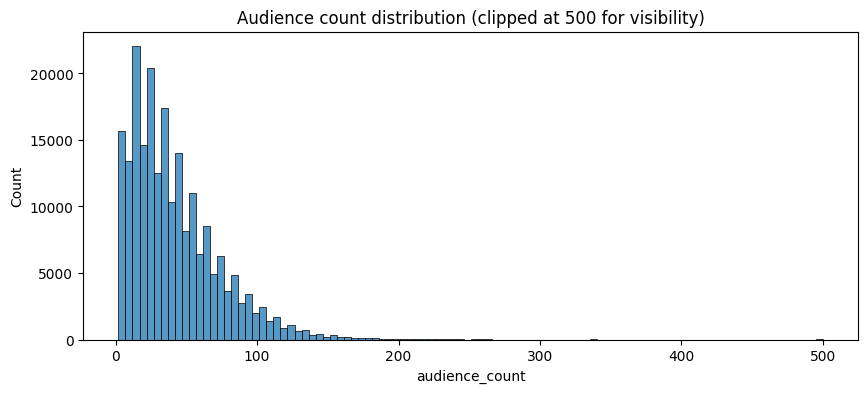

In [28]:
plt.figure(figsize=(10,4))
sns.histplot(booknow_visits['audience_count'].clip(upper=500), bins=100)
plt.title('Audience count distribution (clipped at 500 for visibility)')
plt.show()

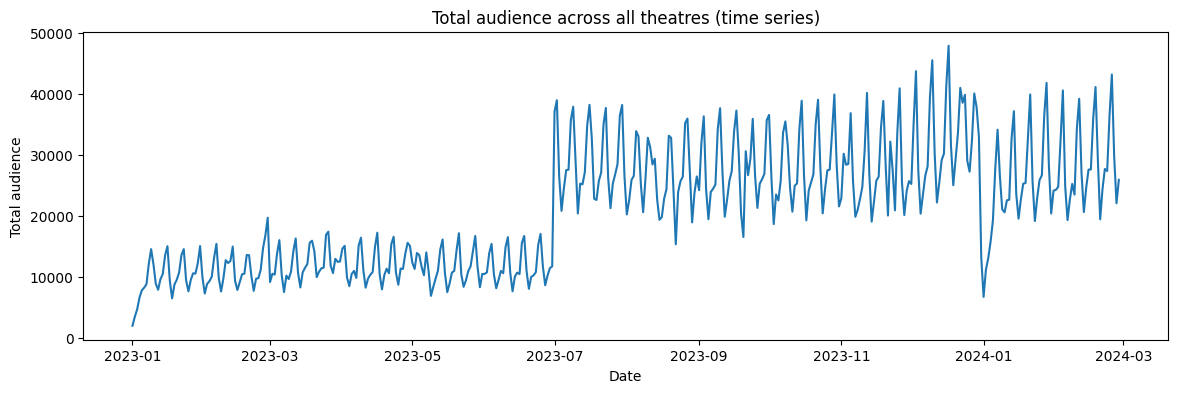

In [29]:
agg = booknow_visits.groupby('show_date')['audience_count'].sum().reset_index()
plt.figure(figsize=(14,4))
plt.plot(agg['show_date'], agg['audience_count'])
plt.title('Total audience across all theatres (time series)')
plt.xlabel('Date')
plt.ylabel('Total audience')
plt.show()

In [30]:
df_merge = booknow_visits.merge(booknow_theaters,on='book_theater_id')

In [31]:
df_merge.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515


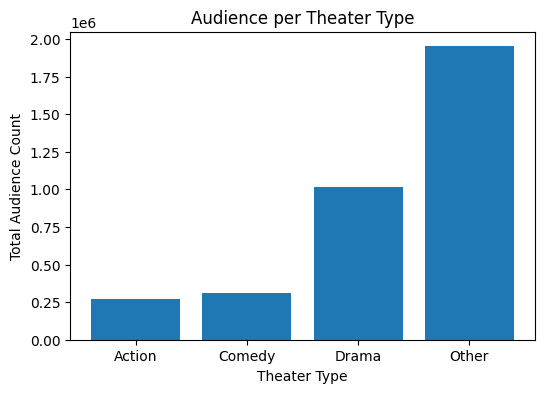

In [32]:
aud_sum = df_merge.groupby('theater_type')['audience_count'].sum().reset_index()


plt.figure(figsize=(6,4))
plt.bar(aud_sum['theater_type'], aud_sum['audience_count'])
plt.xlabel("Theater Type")
plt.ylabel("Total Audience Count")
plt.title("Audience per Theater Type")
plt.show()

In [33]:
movie_map['book_theater_id'].nunique()

150

In [34]:
booknow_booking.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


In [35]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [36]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [37]:
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score,mean_absolute_error

In [38]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [39]:
booknow_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB


In [40]:
booknow_visits.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [41]:
date_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   show_date    547 non-null    datetime64[ns]
 1   day_of_week  547 non-null    object        
dtypes: datetime64[ns](1), object(1)
memory usage: 8.7+ KB


In [42]:
def find_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns
    
    if num_cols.empty:
        print("No numeric columns found.")
        return

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        total_count = len(df)
        
        if outlier_count > 0:
            percentage = (outlier_count / total_count) * 100
            print(f"  {col}: {outlier_count} outliers found ({percentage:.2f}%)")
        else:
            print(f"  {col}: No outliers found.")
    print("-" * 40)
    
find_outliers(booknow_visits)

  audience_count: 5589 outliers found (2.61%)
----------------------------------------


In [43]:
find_outliers(cinePOS_booking)

  tickets_sold: 100686 outliers found (6.13%)
----------------------------------------


In [44]:
find_outliers(booknow_booking)

  tickets_booked: 5542 outliers found (8.11%)
----------------------------------------


In [45]:
find_outliers(booknow_theaters)

  latitude: 77 outliers found (9.29%)
  longitude: No outliers found.
----------------------------------------


In [46]:
def remove_outliers(df):           # using IQR method
    
    num_cols = df.select_dtypes(include=np.number).columns
    
    if num_cols.empty:
        print("No numeric columns found.")
        return

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

    return df

boonow_visits = remove_outliers(booknow_visits)
cinePOS_booking = remove_outliers(cinePOS_booking)
booknow_booking = remove_outliers(booknow_booking)
booknow_theaters = remove_outliers(booknow_theaters)

In [47]:
cinePOS_booking['tickets'] = cinePOS_booking['tickets_sold']
cinePOS_booking['theater_id'] = cinePOS_booking['cine_theater_id']
cinePOS_booking['show_dt'] = cinePOS_booking['show_datetime']
cinePOS_booking['booking_dt'] = cinePOS_booking['booking_datetime']

booknow_booking['tickets'] = booknow_booking['tickets_booked']
booknow_booking['theater_id'] = booknow_booking['book_theater_id']
booknow_booking['show_dt'] = booknow_booking['show_datetime']
booknow_booking['booking_dt'] = booknow_booking['booking_datetime']

all_booking = pd.concat([
    cinePOS_booking[['theater_id', 'show_dt', 'booking_dt', 'tickets']], 
    booknow_booking[['theater_id', 'show_dt', 'booking_dt', 'tickets']]
], ignore_index=True)

In [48]:
all_booking.head()

,theater_id,show_dt,booking_dt,tickets
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1.0
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3.0
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2.0
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5.0
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,12.0


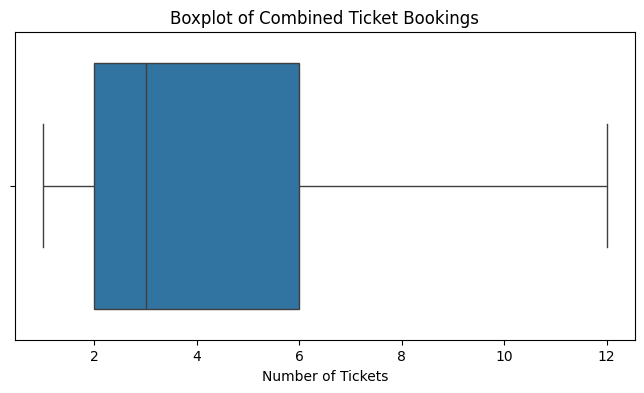

In [49]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=all_booking['tickets'])
plt.title('Boxplot of Combined Ticket Bookings')
plt.xlabel('Number of Tickets')
plt.show()

In [50]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [51]:
# mapping from cine_theater_id to book_theater_id
cine_to_book_map = (
    movie_map.set_index("cine_theater_id")["book_theater_id"].to_dict()
)

all_booking["show_dt"] = pd.to_datetime(all_booking["show_dt"], errors="coerce")
all_booking["booking_dt"] = pd.to_datetime(all_booking["booking_dt"], errors="coerce")

all_booking = all_booking.dropna(subset=["show_dt", "booking_dt"]).copy()

all_booking["show_date"] = all_booking["show_dt"].dt.normalize()  # 

all_booking["booking_lag_hours"] = (
    (all_booking["show_dt"] - all_booking["booking_dt"]).dt.total_seconds() / 3600
)
all_booking["booking_lag_days"] = all_booking["booking_lag_hours"] / 24

In [52]:
all_booking = all_booking[all_booking["booking_lag_hours"] >= 0].copy()

booking_features = (
    all_booking.groupby(["theater_id", "show_date"]).agg(
        total_booked=("tickets", "sum"),
        mean_booked=("tickets", "mean"),
        median_lag_days=("booking_lag_days", "median"),
        booking_count=("tickets", "count"),
    )
    .reset_index()
)

In [53]:
mapped_ids = booking_features["theater_id"].map(cine_to_book_map)
booking_features["book_theater_id"] = mapped_ids.fillna(booking_features["theater_id"]).astype(str)
booking_features = booking_features.drop(columns=["theater_id"]).copy()

In [54]:
booknow_visits = booknow_visits.rename(columns={"audience_count": "target"})
booknow_visits["book_theater_id"] = booknow_visits["book_theater_id"].astype(str)

booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"]) 
date_info["show_date"] = pd.to_datetime(date_info["show_date"]) 
booking_features["show_date"] = pd.to_datetime(booking_features["show_date"])
booknow_visits = pd.merge(booknow_visits, date_info, on="show_date", how="left")

In [55]:
if booknow_theaters["book_theater_id"].dtype != object:
    booknow_theaters["book_theater_id"] = booknow_theaters["book_theater_id"].astype(str)

cols_meta = ["book_theater_id", "theater_type", "theater_area", "latitude", "longitude"]
booknow_visits = pd.merge(
    booknow_visits, 
    booknow_theaters[cols_meta], 
    on="book_theater_id", 
    how="left",
)
booknow_visits = pd.merge(
    booknow_visits, booking_features, on=["book_theater_id", "show_date"], how="left"
)

In [56]:
fill_cols = ["total_booked", "mean_booked", "median_lag_days", "booking_count"]
for col in fill_cols:
    if col in booknow_visits.columns:
        booknow_visits[col] = booknow_visits[col].fillna(0)

if "latitude" in booknow_visits.columns:
    booknow_visits["latitude"] = booknow_visits["latitude"].fillna(booknow_visits["latitude"].mean())
if "longitude" in booknow_visits.columns:
    booknow_visits["longitude"] = booknow_visits["longitude"].fillna(booknow_visits["longitude"].mean())

for c in ["theater_type", "theater_area"]:
    if c in booknow_visits.columns:
        booknow_visits[c] = booknow_visits[c].fillna("Missing")

In [57]:
booknow_visits["year"] = booknow_visits["show_date"].dt.year
booknow_visits["month"] = booknow_visits["show_date"].dt.month
booknow_visits["day"] = booknow_visits["show_date"].dt.day
booknow_visits["week_of_year"] = booknow_visits["show_date"].dt.isocalendar().week.astype(int)

if "day_of_week" in booknow_visits.columns:
    booknow_visits["is_weekend"] = booknow_visits["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
else:
    booknow_visits["is_weekend"] = (booknow_visits["show_date"].dt.weekday >= 5).astype(int)

In [58]:

theater_stats = booknow_visits.groupby("book_theater_id")["target"].mean().rename("theater_mean")
booknow_visits = booknow_visits.merge(theater_stats, on="book_theater_id", how="left")

if "day_of_week" in booknow_visits.columns:
    theater_dow_stats = (
        booknow_visits.groupby(["book_theater_id", "day_of_week"])["target"]
        .mean()
        .rename("theater_dow_mean")
    )
    booknow_visits = booknow_visits.merge(theater_dow_stats, on=["book_theater_id", "day_of_week"], how="left")
    if "theater_dow_mean" in booknow_visits.columns:
        booknow_visits["theater_dow_mean"] = booknow_visits["theater_dow_mean"].fillna(booknow_visits["theater_mean"])
    else:
        booknow_visits["theater_dow_mean"] = booknow_visits["theater_mean"]
else:
    booknow_visits["theater_dow_mean"] = booknow_visits["theater_mean"]

global_mean = booknow_visits["target"].mean()
if "theater_mean" in booknow_visits.columns:
    booknow_visits["theater_mean"] = booknow_visits["theater_mean"].fillna(global_mean)
else:
    booknow_visits["theater_mean"] = global_mean
    
if "theater_dow_mean" in booknow_visits.columns:
    booknow_visits["theater_dow_mean"] = booknow_visits["theater_dow_mean"].fillna(global_mean)
else:
    booknow_visits["theater_dow_mean"] = global_mean

booknow_visits = remove_outliers(booknow_visits)


booknow_visits["ID"] = (
    booknow_visits["book_theater_id"].astype(str)
    + "_"
    + booknow_visits["show_date"].dt.strftime("%Y-%m-%d")
)

split_date = booknow_visits["show_date"].max() - pd.DateOffset(months=2)
train_df = booknow_visits[booknow_visits["show_date"] <= split_date].copy()
test_df = booknow_visits[booknow_visits["show_date"] > split_date].copy()

train_df = train_df.sample(frac=0.1, random_state=42).copy() if len(train_df) > 0 else train_df

X_train = train_df.drop(columns=["target", "show_date", "ID"], errors="ignore")
y_train = train_df["target"]
X_test = test_df.drop(columns=["target", "show_date", "ID"], errors="ignore")

test_ids = test_df["ID"].values

print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"X_train columns: {X_train.columns.tolist()}")


Train set size: 17564, Test set size: 42700
X_train columns: ['book_theater_id', 'day_of_week', 'theater_type', 'theater_area', 'latitude', 'longitude', 'total_booked', 'mean_booked', 'median_lag_days', 'booking_count', 'year', 'month', 'day', 'week_of_year', 'is_weekend', 'theater_mean', 'theater_dow_mean']


In [59]:
booknow_visits.head()

,book_theater_id,show_date,target,day_of_week,theater_type,theater_area,latitude,longitude,total_booked,mean_booked,median_lag_days,booking_count,year,month,day,week_of_year,is_weekend,theater_mean,theater_dow_mean,ID
0,book_00001,2023-01-13,50.0,Friday,Drama,Area_002,22.865377,78.929514,0.0,0.0,0.0,0.0,2023.0,1.0,13.0,2.0,0.0,47.046784,43.719298,book_00001_2023-01-13
1,book_00001,2023-01-14,64.0,Saturday,Drama,Area_002,22.865377,78.929514,0.0,0.0,0.0,0.0,2023.0,1.0,14.0,2.0,1.0,47.046784,66.771930,book_00001_2023-01-14
2,book_00001,2023-01-15,58.0,Sunday,Drama,Area_002,22.865377,78.929514,0.0,0.0,0.0,0.0,2023.0,1.0,15.0,2.0,1.0,47.046784,59.758621,book_00001_2023-01-15
3,book_00001,2023-01-16,44.0,Monday,Drama,Area_002,22.865377,78.929514,0.0,0.0,0.0,0.0,2023.0,1.0,16.0,3.0,0.0,47.046784,19.600000,book_00001_2023-01-16
4,book_00001,2023-01-18,12.0,Wednesday,Drama,Area_002,22.865377,78.929514,0.0,0.0,0.0,0.0,2023.0,1.0,18.0,3.0,0.0,47.046784,38.618182,book_00001_2023-01-18


In [60]:
print(date_info.columns)
print(booknow_visits.columns)
print(test_df.columns)

Index(['show_date', 'day_of_week'], dtype='object')
Index(['book_theater_id', 'show_date', 'target', 'day_of_week', 'theater_type',
       'theater_area', 'latitude', 'longitude', 'total_booked', 'mean_booked',
       'median_lag_days', 'booking_count', 'year', 'month', 'day',
       'week_of_year', 'is_weekend', 'theater_mean', 'theater_dow_mean', 'ID'],
      dtype='object')
Index(['book_theater_id', 'show_date', 'target', 'day_of_week', 'theater_type',
       'theater_area', 'latitude', 'longitude', 'total_booked', 'mean_booked',
       'median_lag_days', 'booking_count', 'year', 'month', 'day',
       'week_of_year', 'is_weekend', 'theater_mean', 'theater_dow_mean', 'ID'],
      dtype='object')


In [61]:
y_test = test_df['target']

In [62]:
y_test.shape

(42700,)

In [63]:
# Preprocessing

In [64]:
numerical_features = ['latitude', 'longitude', 'total_booked', 'mean_booked', 'median_lag_days', 
                      'booking_count', 'year', 'month', 'day', 'week_of_year', 'is_weekend',
                      'theater_mean', 'theater_dow_mean']
categorical_ohe = ['theater_type', 'theater_area', 'day_of_week']


te_kwargs = dict(min_samples_leaf=10, smoothing=5.0, handle_unknown='value', handle_missing='value')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [f for f in numerical_features if f != 'is_weekend']),
        ('bin', 'passthrough', ['is_weekend']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_ohe)
    ],
    remainder='drop'
)


In [65]:
# Model 1 - Random Forest Regressor

In [66]:
model = RandomForestRegressor(
    n_estimators=400,           
    max_depth=5,
    min_samples_split= 10,        
    min_samples_leaf=60,   
    random_state=42, 
    n_jobs=-1
)

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', model)])


In [67]:
full_pipeline.fit(X_train, y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'total_booked',
                                                   'mean_booked',
                                                   'median_lag_days',
                                                   'booking_count', 'year',
                                                   'month', 'day',
                                                   'week_of_year',
                                                   'theater_mean',
                                                   'theater_dow_mean']),
                                                 ('bin', 'passthrough',
                                                  ['is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['theater_type',
                                                   'theater_area',
                                                   'day_of_week'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=60,
                                       min_samples_split=10, n_estimators=400,
                                       n_jobs=-1, random_state=42))])

In [68]:
X_test.shape

(42700, 17)

In [69]:
y_pred = full_pipeline.predict(X_test)

y_pred = np.maximum(0, y_pred)
y_pred = np.round(y_pred).astype(int)

In [70]:
from sklearn.metrics import mean_absolute_error,r2_score

In [71]:
mean_absolute_error(y_test,y_pred)

13.498758782201405

In [72]:
r2_score(y_test,y_pred)

0.6061969516231417

In [73]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [74]:
xgb_base = XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=4,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)
full_pipeline1 = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', xgb_base)])

print("Training model...")


Training model...


In [75]:
full_pipeline1.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'total_booked',
                                                   'mean_booked',
                                                   'median_lag_days',
                                                   'booking_count', 'year',
                                                   'month', 'day',
                                                   'week_of_year',
                                                   'theater_mean',
                                                   'theater_dow_mean']),
                                                 ('bin', 'passthrough',
                                                  ['is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=50, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [76]:
y_pred = full_pipeline1.predict(X_test)
y_pred = np.maximum(0, y_pred)
y_pred = np.round(y_pred).astype(int)
mean_absolute_error(y_test,y_pred)

14.09943793911007

In [77]:
r2_score(y_test,y_pred)

0.5864048285907462

In [78]:
lgm_base = LGBMRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=3,              
    num_leaves=50,
    random_state=42,
)
full_pipeline2 = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', lgm_base)])

print("Training model...")


Training model...


In [79]:
full_pipeline2.fit(X_train,y_train)
y_pred=  full_pipeline2.predict(X_test)
y_pred = np.maximum(0, y_pred)
y_pred = np.round(y_pred).astype(int)
mean_absolute_error(y_test,y_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 748
[LightGBM] [Info] Number of data points in the train set: 17564, number of used features: 75
[LightGBM] [Info] Start training from score 41.092006
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

13.890585480093677

In [80]:
r2_score(y_test, y_pred)

0.5952086149790837

In [81]:
y_train.shape
y_test.shape

(42700,)

In [82]:
# Hyperparameter Tuning

In [85]:
rf_param_grid = {
    "model__n_estimators": [50,100,200,300,350,400,420,450,500],
    "model__max_depth": [2,5,8,10, 15, 20, 30, None],
    "model__min_samples_split": [1,2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 50],
    "model__max_features": ["auto", "sqrt", "log2"]
}
pipe_rf = Pipeline([
    ('preprocess',preprocessor),
    ('model',RandomForestRegressor(random_state = 42))
])
rf_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=rf_param_grid,
    n_iter=50,                
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF Score (RMSE):", np.sqrt(-rf_search.best_score_))
print("RF MAE on Test:", mean_absolute_error(y_test, rf_search.predict(X_test)))

best_rf = rf_search.best_estimator_


Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\Akshit Maheshwari\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
69 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
31 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Akshit Maheshwari\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Akshit Maheshwari\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Best RF Params: {'model__n_estimators': 420, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best RF Score (RMSE): 18.827245089470285
RF MAE on Test: 14.985648843405412


In [86]:
y_pred = best_rf.predict(X_test)
r2_score(y_test,y_pred)

0.5420360026412726